In [1]:
# Ryan Dunne
#C00263405

## Music Genre Classifier with RNN (GTZAN Dataset)

Link to Dataset:  https://www.kaggle.com/datasets/andradaolteanu/gtzan-dataset-music-genre-classification

Some assistance from this YT video: https://www.youtube.com/watch?v=4nXI0h2sq2I

Recurrent Neural Network (RNN/LSTM) to classify music genres using the GTZAN dataset

**Genres Used** blues, classical, country, disco, hiphop, jazz, metal, pop, reggae, rock


In [22]:
import os
import json
import math
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from tqdm import tqdm
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM, GRU, Dense, Dropout, BatchNormalization,
    Bidirectional, Input
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow version: {tf.__version__}")
print(f"librosa version:    {librosa.__version__}")
print(f"GPUs available:     {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.21.0
librosa version:    0.11.0
GPUs available:     []


In [23]:
DATASET_PATH = Path("Data/genres_original")

genres = sorted([d.name for d in DATASET_PATH.iterdir() if d.is_dir()])
print(f"Genres found ({len(genres)}): {genres}")

total_files = sum(len(list((DATASET_PATH / g).glob("*.wav"))) for g in genres)
print(f"Total audio files: {total_files}")

Genres found (10): ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
Total audio files: 1000


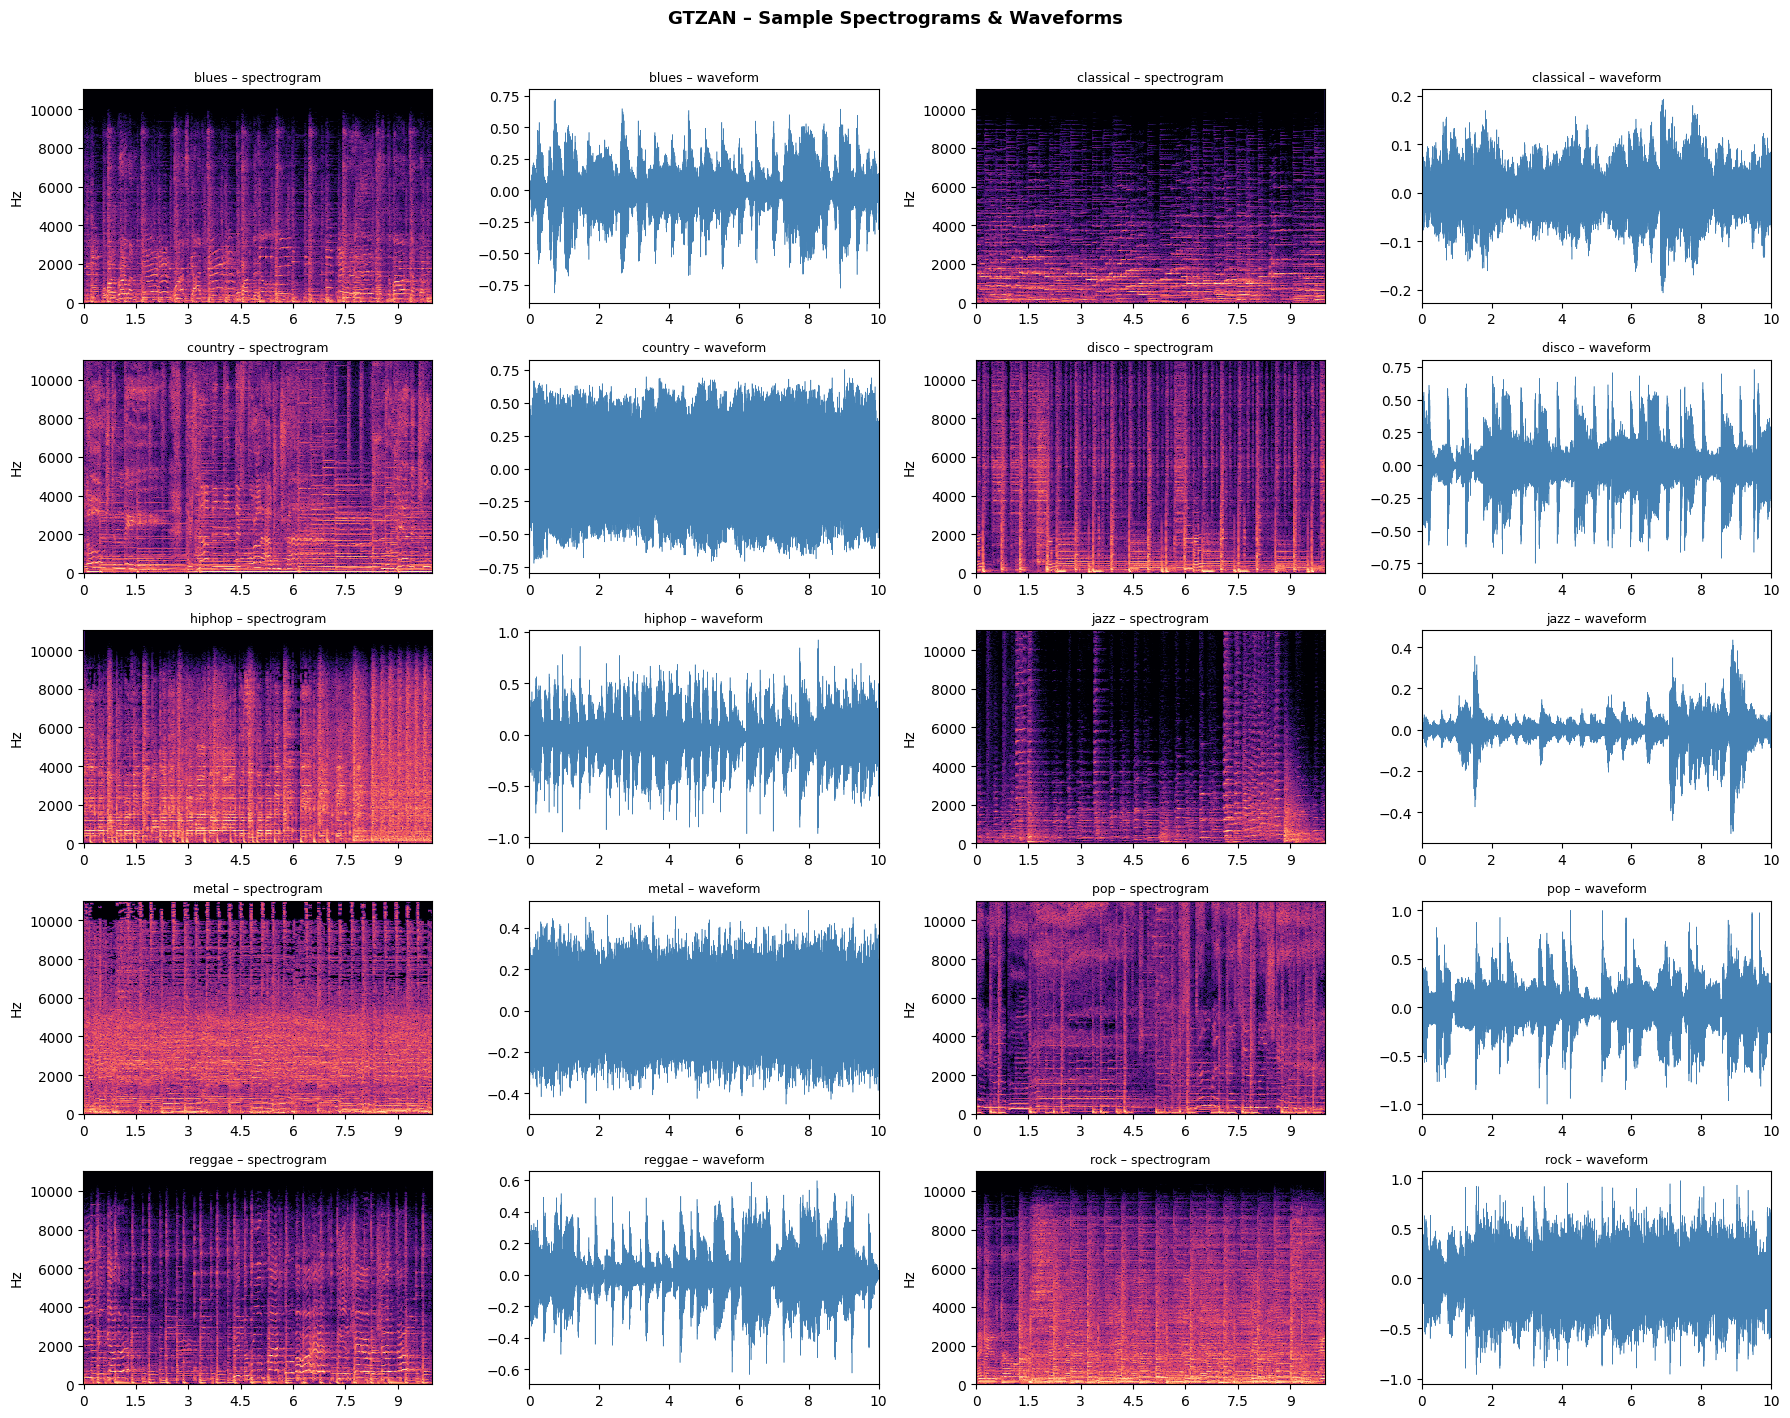

In [24]:
# Visualise one waveform + spectrogram per genre 
fig, axes = plt.subplots(5, 4, figsize=(18, 14))
axes = axes.flatten()

for i, genre in enumerate(genres):
    sample_path = next((DATASET_PATH / genre).glob("*.wav"))
    y, sr = librosa.load(sample_path, duration=10, sr=22050)
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    librosa.display.specshow(D, sr=sr, ax=axes[2*i], x_axis="time", y_axis="hz", cmap="magma")
    axes[2*i].set_title(f"{genre} – spectrogram", fontsize=9)
    axes[2*i].set_xlabel("")
    axes[2*i+1].plot(np.linspace(0, 10, len(y)), y, linewidth=0.4, color="steelblue")
    axes[2*i+1].set_title(f"{genre} – waveform", fontsize=9)
    axes[2*i+1].set_xlim(0, 10)

plt.suptitle("GTZAN – Sample Spectrograms & Waveforms", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

In [25]:
# Config
SAMPLE_RATE   = 22050
DURATION      = 30          # full track length (seconds)
SEGMENT_DUR   = 3           # seconds per segment fed to RNN
HOP_LENGTH    = 512
N_MFCC        = 13
N_MELS        = 128
N_FFT         = 2048

samples_per_seg = SAMPLE_RATE * SEGMENT_DUR
frames_per_seg  = math.ceil(samples_per_seg / HOP_LENGTH)
n_segments      = DURATION // SEGMENT_DUR  # 10 segments × 100 tracks = 1 000 per genre

print(f"Segments per track : {n_segments}")
print(f"Frames per segment : {frames_per_seg}")

Segments per track : 10
Frames per segment : 130


In [26]:
def extract_features(signal, sr):
    """Return a (frames, features) array for one segment."""
    mfcc       = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=N_MFCC, n_fft=N_FFT, hop_length=HOP_LENGTH)
    mfcc_delta = librosa.feature.delta(mfcc)
    chroma     = librosa.feature.chroma_stft(y=signal, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH)
    centroid   = librosa.feature.spectral_centroid(y=signal, sr=sr, hop_length=HOP_LENGTH)
    bandwidth  = librosa.feature.spectral_bandwidth(y=signal, sr=sr, hop_length=HOP_LENGTH)
    rolloff    = librosa.feature.spectral_rolloff(y=signal, sr=sr, hop_length=HOP_LENGTH)
    zcr        = librosa.feature.zero_crossing_rate(signal, hop_length=HOP_LENGTH)

    # Stack all → shape (n_features, frames), then transpose to (frames, n_features)
    features = np.vstack([mfcc, mfcc_delta, chroma, centroid, bandwidth, rolloff, zcr])
    return features.T   # (frames, 42)


def build_dataset(dataset_path, genres, n_segments, samples_per_seg, sr=SAMPLE_RATE):
    """Walk the dataset and extract features for every segment."""
    X, y = [], []

    for label, genre in enumerate(genres):
        genre_path = dataset_path / genre
        files = sorted(genre_path.glob("*.wav"))
        print(f"  Processing '{genre}' ({len(files)} files)…")

        for fp in tqdm(files, leave=False):
            try:
                signal, _ = librosa.load(fp, sr=sr, mono=True)
            except Exception as e:
                print(f"    ⚠  Skipping {fp.name}: {e}")
                continue

            for seg in range(n_segments):
                start = samples_per_seg * seg
                end   = start + samples_per_seg
                chunk = signal[start:end]
                if len(chunk) < samples_per_seg:
                    continue   # skip short last segment

                feat = extract_features(chunk, sr)
                X.append(feat)
                y.append(label)

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32)


print("Extracting features – this takes a few minutes on CPU…")
X, y = build_dataset(DATASET_PATH, genres, n_segments, samples_per_seg)
print(f"\nDone!  X shape: {X.shape}  |  y shape: {y.shape}")
print(f"Feature vector size per frame: {X.shape[2]}")

Extracting features – this takes a few minutes on CPU…
  Processing 'blues' (100 files)…


  Processing 'classical' (100 files)…


  Processing 'country' (100 files)…


  Processing 'disco' (100 files)…


  Processing 'hiphop' (100 files)…


...

  Processing 'metal' (100 files)…


  Processing 'pop' (100 files)…


  Processing 'reggae' (100 files)…


  Processing 'rock' (100 files)…



Done!  X shape: (9981, 130, 42)  |  y shape: (9981,)
Feature vector size per frame: 42


In [27]:
# Save / load extracted features (so you don't re-extract every run) 
np.save("X_gtzan.npy", X)
np.save("y_gtzan.npy", y)
print("Features saved to disk.")

# To reload: X = np.load('X_gtzan.npy'); y = np.load('y_gtzan.npy')

Features saved to disk.


## Preprocess & Split

In [9]:
# Normalise features (zero-mean, unit-variance per feature dimension) 
mean = X.mean(axis=(0, 1), keepdims=True)
std  = X.std(axis=(0, 1), keepdims=True) + 1e-8
X_norm = (X - mean) / std

# One-hot encode labels 
NUM_CLASSES = len(genres)
y_cat = to_categorical(y, num_classes=NUM_CLASSES)

#  Train / Validation / Test split (70 / 15 / 15) 
X_train, X_temp, y_train, y_temp = train_test_split(
    X_norm, y_cat, test_size=0.30, random_state=SEED, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp.argmax(1))

print(f"Train : {X_train.shape}")
print(f"Val   : {X_val.shape}")
print(f"Test  : {X_test.shape}")
print(f"Input shape for RNN: (timesteps={X_train.shape[1]}, features={X_train.shape[2]})")

Train : (6986, 130, 42)
Val   : (1497, 130, 42)
Test  : (1498, 130, 42)
Input shape for RNN: (timesteps=130, features=42)


## Build the Bidirectional LSTM Model

Architecture:
```
Input → BiLSTM(128) → Dropout → BiLSTM(64) → Dropout → BatchNorm → Dense(64) → Dropout → Softmax(10)
```

In [10]:
TIME_STEPS = X_train.shape[1]
N_FEATURES = X_train.shape[2]

def build_model(time_steps, n_features, n_classes):
    model = Sequential([
        Input(shape=(time_steps, n_features)),

        # First Bidirectional LSTM block
        Bidirectional(LSTM(128, return_sequences=True)),
        Dropout(0.3),

        # Second Bidirectional LSTM block
        Bidirectional(LSTM(64, return_sequences=False)),
        Dropout(0.3),
        BatchNormalization(),

        # Classifier head
        Dense(64, activation="relu"),
        Dropout(0.3),
        Dense(n_classes, activation="softmax"),
    ], name="BiLSTM_Genre_Classifier")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


model = build_model(TIME_STEPS, N_FEATURES, NUM_CLASSES)
model.summary()

Model: "BiLSTM_Genre_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)        │ (None, 130, 256)            │         175,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 130, 256)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ (None, 128)                 │         164,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 348,874 (1.33 MB)

 Trainable params: 348,618 (1.33 MB)

 Non-trainable params: 256 (1.00 KB)

## Train Model

stuck with 20 epochs due to lack of patience

In [11]:
callbacks = [
    EarlyStopping(monitor="val_accuracy", patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=7, min_lr=1e-6, verbose=1),
    ModelCheckpoint("best_model.keras", monitor="val_accuracy", save_best_only=True, verbose=0),
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=64,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 36s 230ms/step - accuracy: 0.3640 - loss: 1.8257 - val_accuracy: 0.4890 - val_loss: 1.5481 - learning_rate: 0.0010
Epoch 2/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 24s 214ms/step - accuracy: 0.5162 - loss: 1.3685 - val_accuracy: 0.5618 - val_loss: 1.2583 - learning_rate: 0.0010
Epoch 3/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 23s 211ms/step - accuracy: 0.5949 - loss: 1.1555 - val_accuracy: 0.6273 - val_loss: 1.0677 - learning_rate: 0.0010
Epoch 4/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 24s 216ms/step - accuracy: 0.6679 - loss: 0.9736 - val_accuracy: 0.6306 - val_loss: 1.0907 - learning_rate: 0.0010
Epoch 5/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 23s 212ms/step - accuracy: 0.7203 - loss: 0.8373 - val_accuracy: 0.6887 - val_loss: 0.9117 - learning_rate: 0.0010
Epoch 6/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 23s 206ms/step - accuracy: 0.7671 - loss: 0.6968 - val_accuracy: 0.7268 - val_loss: 0.8693 - learning_rate: 0.0010
Epoch 7/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 23s 207ms/step - accuracy: 0.7

## Training Curves

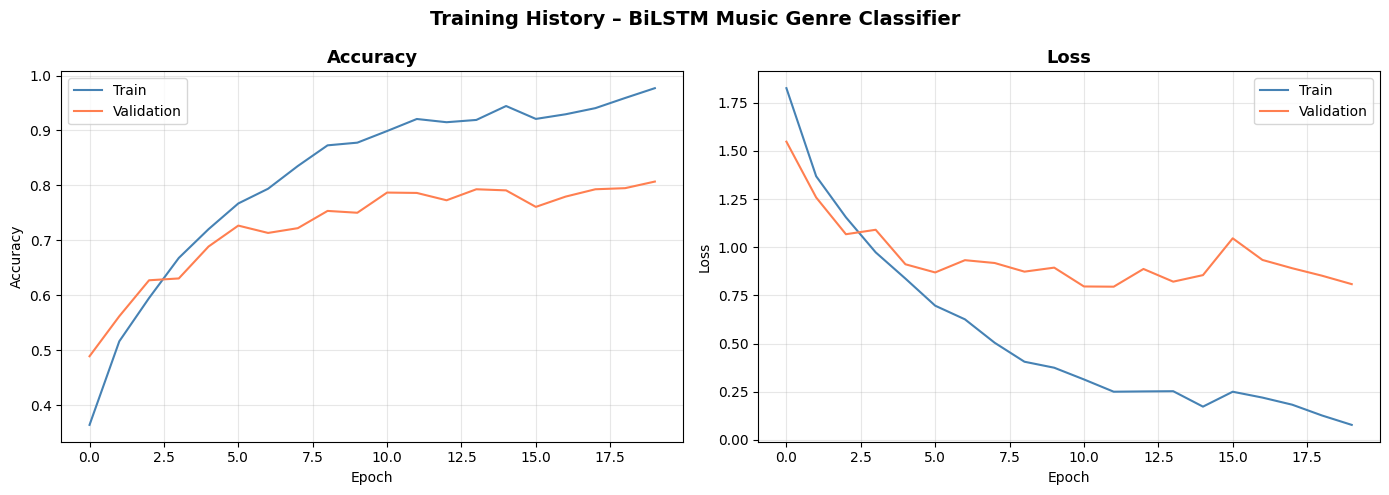

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(history.history["accuracy"],     label="Train",      color="steelblue")
ax1.plot(history.history["val_accuracy"], label="Validation", color="coral")
ax1.set_title("Accuracy", fontsize=13, fontweight="bold")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Accuracy")
ax1.legend(); ax1.grid(alpha=0.3)

# Loss
ax2.plot(history.history["loss"],     label="Train",      color="steelblue")
ax2.plot(history.history["val_loss"], label="Validation", color="coral")
ax2.set_title("Loss", fontsize=13, fontweight="bold")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Loss")
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle("Training History – BiLSTM Music Genre Classifier", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Try on Test Set

In [13]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc*100:.2f}%")

Test Loss     : 0.8646
Test Accuracy : 82.64%


In [14]:
#  Full classification report 
y_pred  = model.predict(X_test, verbose=0).argmax(axis=1)
y_true  = y_test.argmax(axis=1)

print(classification_report(y_true, y_pred, target_names=genres))

              precision    recall  f1-score   support

       blues       0.85      0.81      0.83       150
   classical       0.92      0.98      0.95       150
     country       0.82      0.71      0.76       150
       disco       0.75      0.83      0.79       150
      hiphop       0.82      0.84      0.83       150
        jazz       0.84      0.87      0.86       148
       metal       0.92      0.87      0.89       150
         pop       0.84      0.88      0.86       150
      reggae       0.79      0.79      0.79       150
        rock       0.73      0.69      0.71       150

    accuracy                           0.83      1498
   macro avg       0.83      0.83      0.83      1498
weighted avg       0.83      0.83      0.83      1498



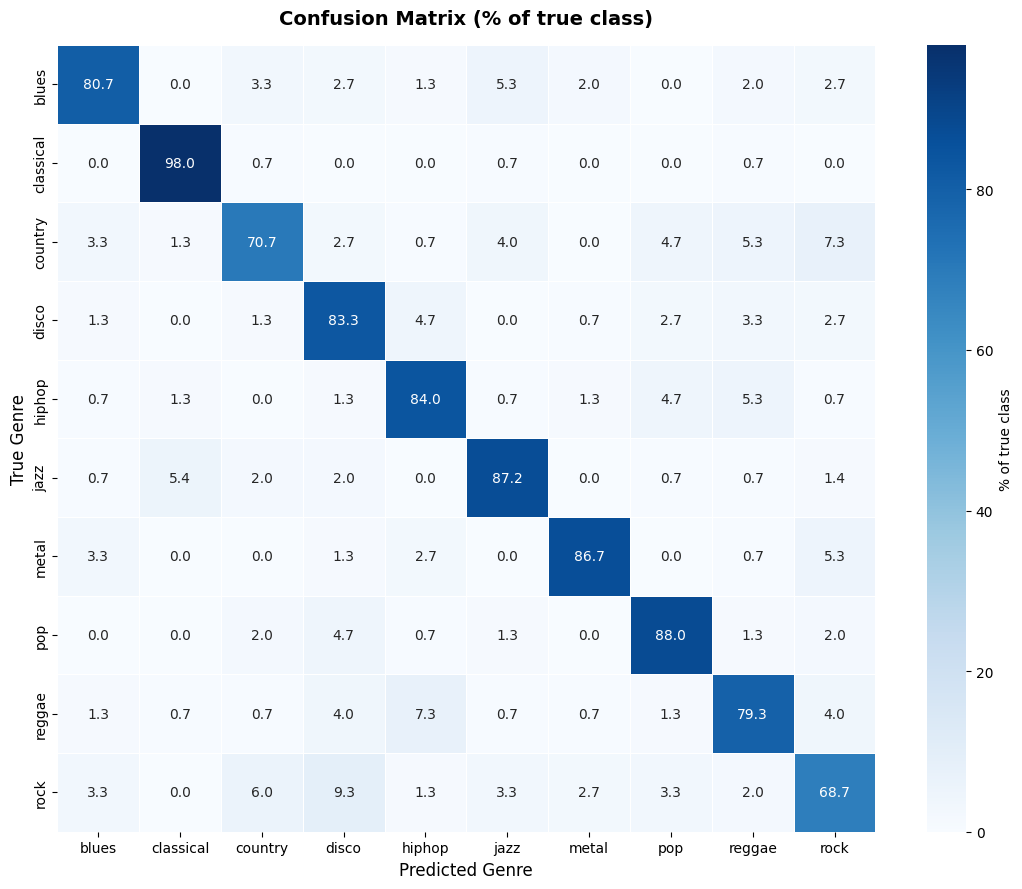

In [15]:
# Confusion matrix 
cm = confusion_matrix(y_true, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(cm_pct, annot=True, fmt=".1f", cmap="Blues",
            xticklabels=genres, yticklabels=genres,
            linewidths=0.5, ax=ax, cbar_kws={"label": "% of true class"})
ax.set_title("Confusion Matrix (% of true class)", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Predicted Genre", fontsize=12)
ax.set_ylabel("True Genre", fontsize=12)
plt.tight_layout()
plt.show()

## Accuracy For Each Genre Bar Chart

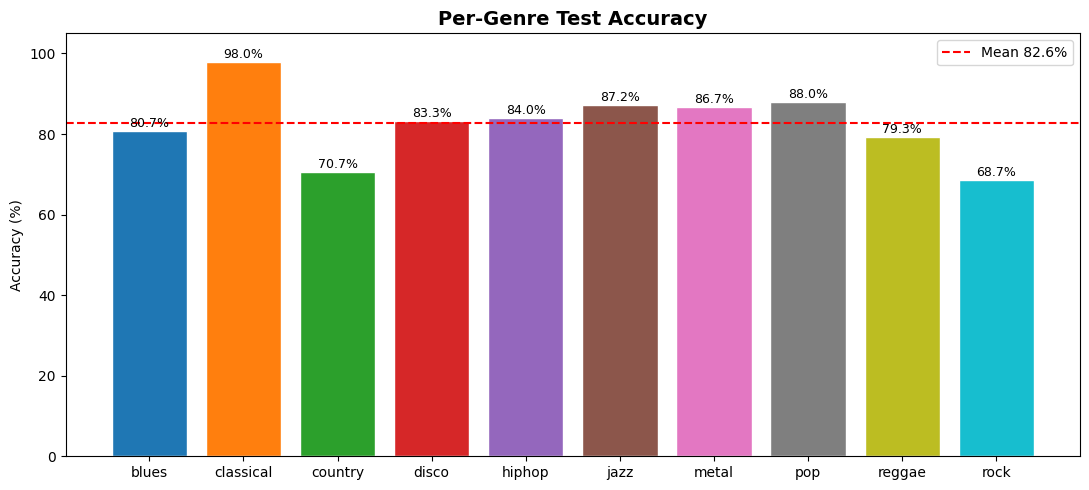

In [17]:
per_genre_acc = cm.diagonal() / cm.sum(axis=1) * 100

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(genres, per_genre_acc, color=plt.cm.tab10(np.linspace(0, 1, NUM_CLASSES)), edgecolor="white")
ax.axhline(per_genre_acc.mean(), color="red", linestyle="--", label=f"Mean {per_genre_acc.mean():.1f}%")
ax.set_title("Per-Genre Test Accuracy", fontsize=14, fontweight="bold")
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(0, 105)
ax.legend()
for bar, val in zip(bars, per_genre_acc):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1, f"{val:.1f}%", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

## Predict Genre based on provided file

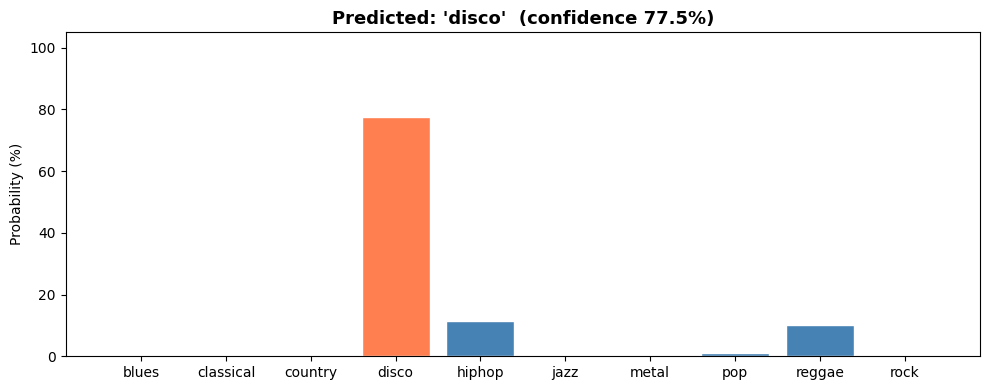

True genre: disco   |   Predicted: disco


In [20]:
def predict_genre(filepath, model, genres, mean, std, sr=SAMPLE_RATE,
                  seg_dur=SEGMENT_DUR, n_segments=n_segments):
    """Predict genre for a single .wav file by majority vote across segments."""
    signal, _ = librosa.load(filepath, sr=sr, mono=True)
    samples_per_seg = sr * seg_dur
    preds = []

    for seg in range(n_segments):
        start = samples_per_seg * seg
        chunk = signal[start : start + samples_per_seg]
        if len(chunk) < samples_per_seg:
            continue
        feat = extract_features(chunk, sr)
        feat_norm = (feat - mean[0]) / std[0]       
        feat_norm = feat_norm[np.newaxis, ...]  
        prob = model.predict(feat_norm, verbose=0)[0]
        preds.append(prob)

    avg_prob  = np.mean(preds, axis=0)
    pred_idx  = avg_prob.argmax()
    pred_genre = genres[pred_idx]

    # Plot probability distribution
    fig, ax = plt.subplots(figsize=(10, 4))
    colors = ["steelblue" if i != pred_idx else "coral" for i in range(len(genres))]
    ax.bar(genres, avg_prob * 100, color=colors, edgecolor="white")
    ax.set_title(f"Predicted: '{pred_genre}'  (confidence {avg_prob[pred_idx]*100:.1f}%)",
                 fontsize=13, fontweight="bold")
    ax.set_ylabel("Probability (%)")
    ax.set_ylim(0, 105)
    plt.tight_layout()
    plt.show()

    return pred_genre, avg_prob


# predict a random test file
sample_genre = "disco" # cahnge genres
sample_file  = next((DATASET_PATH / sample_genre).glob("*.wav"))

pred, probs = predict_genre(sample_file, model, genres, mean, std)
print(f"True genre: {sample_genre}   |   Predicted: {pred}")